#  Análise Exploratória de Dados - Análise Bivariada: Goodreads Dataset

In [1]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))


# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nossos módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb

---

## Carregando Dados

In [21]:
caminho = '../data/interim/books/goodreads_books_enriched.parquet'
df_books = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (10897, 18)


---
## Numérica VS Numérica

In [23]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_books.select_dtypes(include='number')
        .corr(method='pearson')['total_votes']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Pearson)'
))

display(tb.estilizar_matriz_correlacao(
    df_corr=df_books.select_dtypes(include='number')
        .corr(method='spearman')['total_votes']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Spearman)'
))

,Correlação
total_votes,1.000000
votes_per_year,0.990686
text_reviews_count,0.865908
release_year,0.044841
decade,0.042990
global_score,0.041521
average_rating,0.041521
num_pages,0.032434
age_years,-0.044841
book_id,-0.077257


,Correlação
total_votes,1.000000
votes_per_year,0.995311
text_reviews_count,0.957020
num_pages,0.165469
release_year,0.114581
decade,0.100460
global_score,0.082008
average_rating,0.082008
book_id,-0.098546
age_years,-0.114581


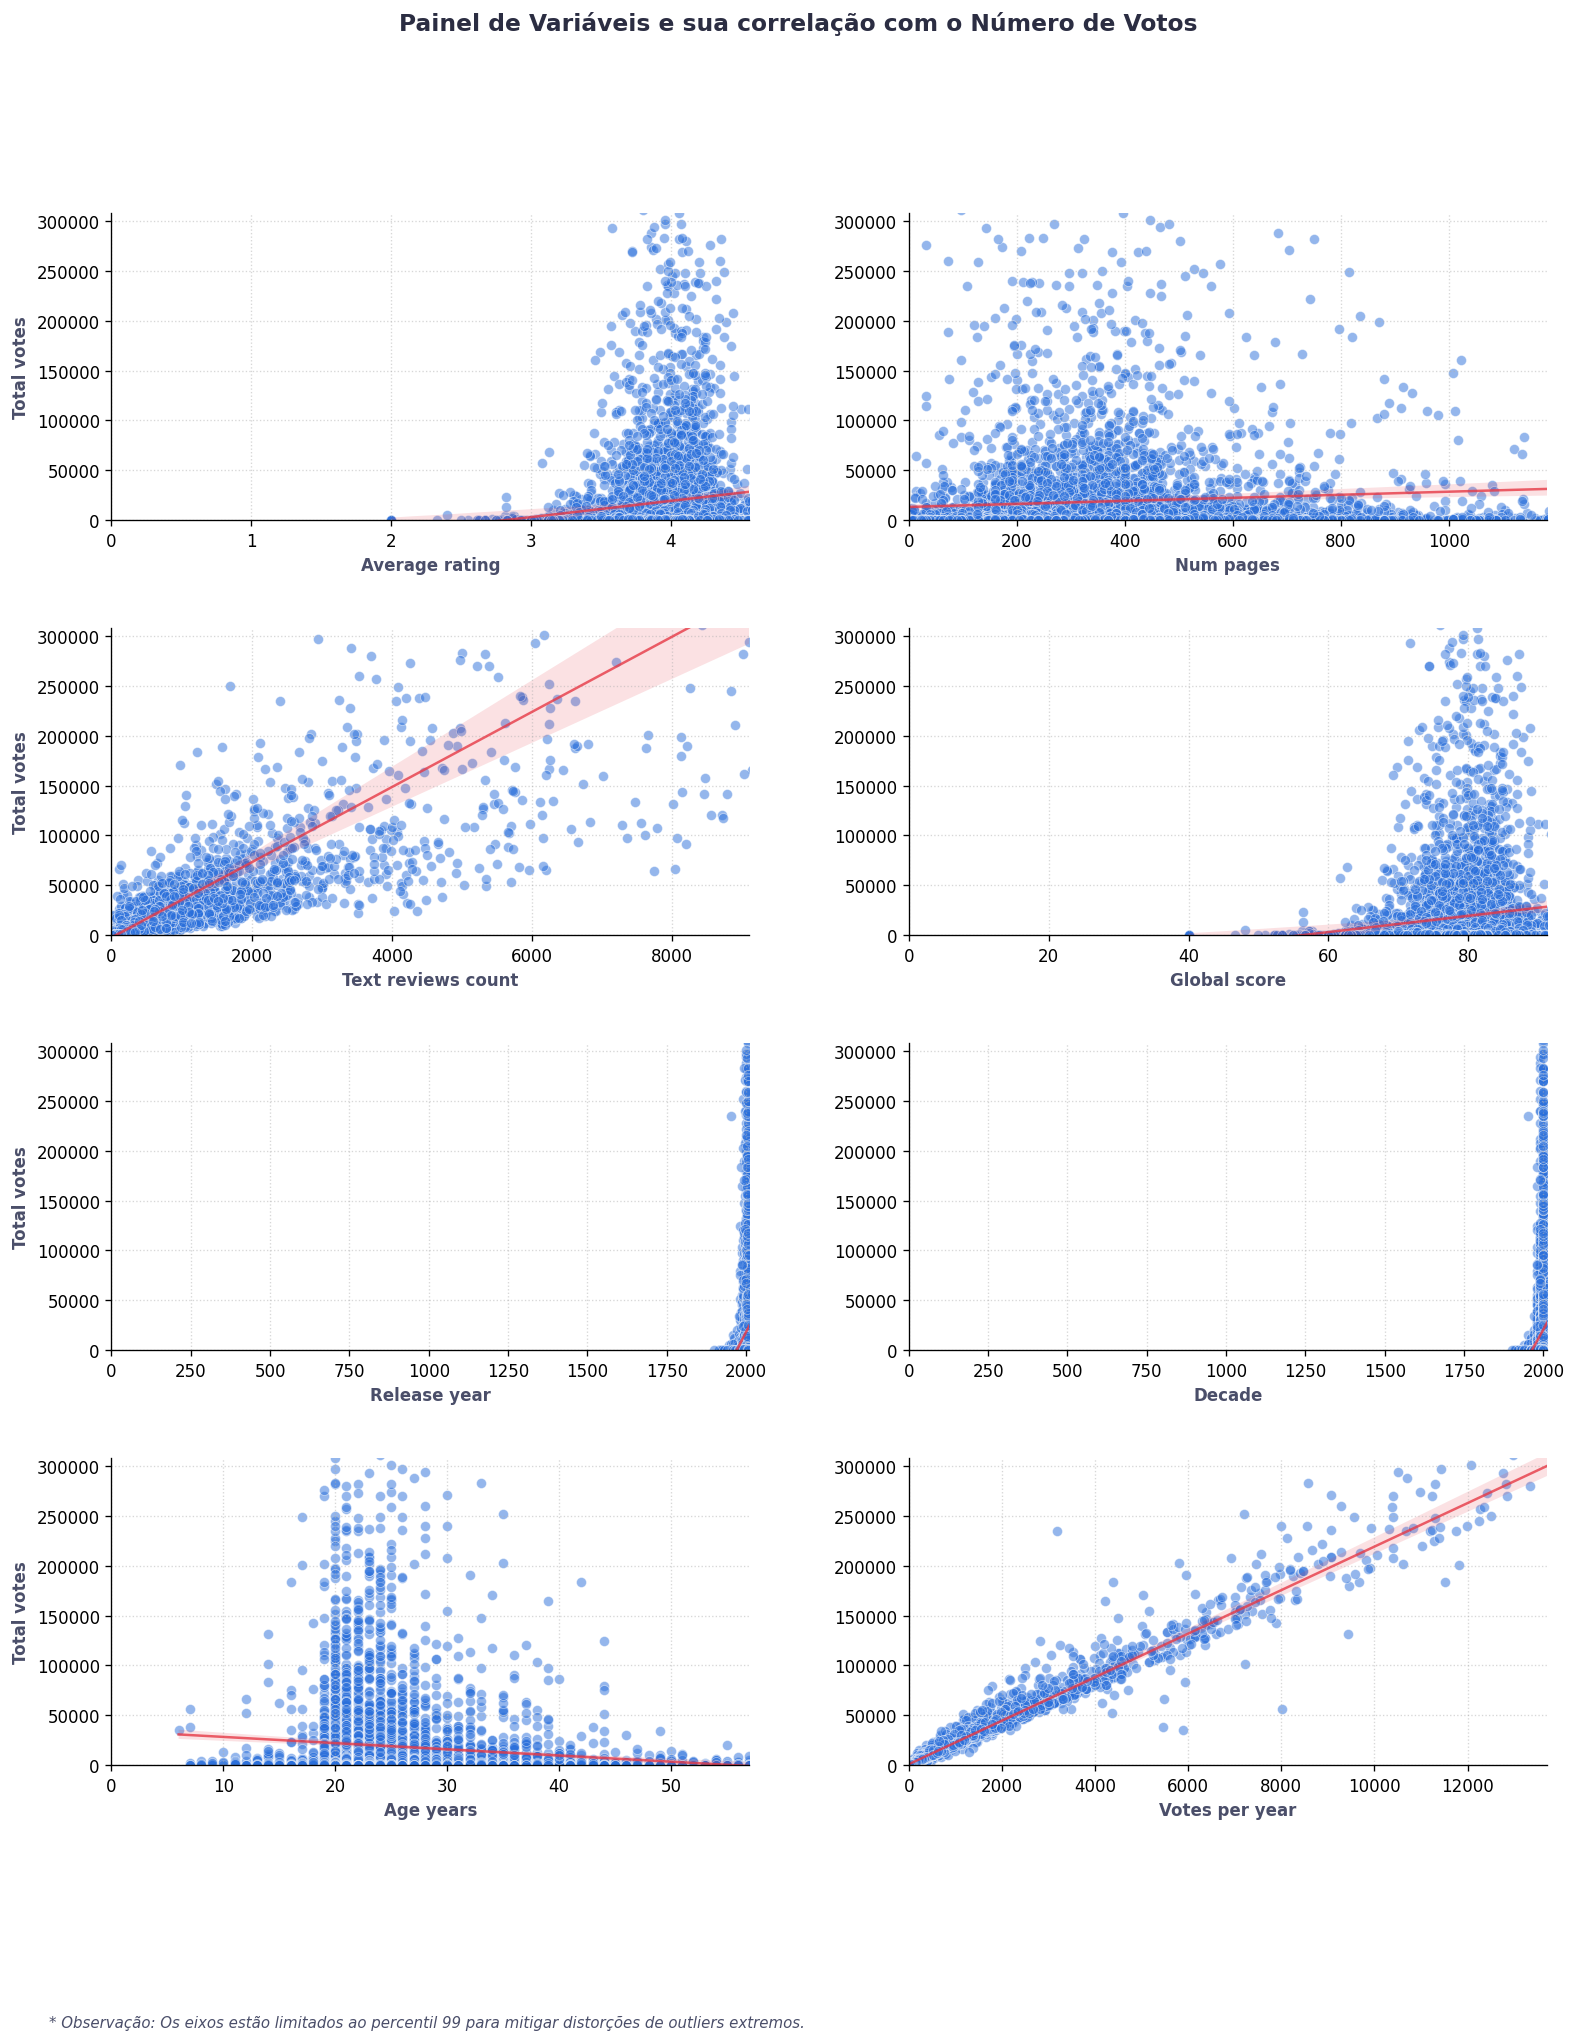

In [25]:
colunas_numericas = df_books.select_dtypes(include='number').columns


graf.grafico_corr_scatter(
    df_plot=df_books,
    coluna_x=colunas_numericas.drop(['total_votes', 'book_id']),
    coluna_y='total_votes',
    titulo='Painel de Variáveis e sua correlação com o Número de Votos',
    quant_grafs=len(colunas_numericas.drop(['total_votes', 'book_id']))
)

In [26]:
display(tb.estilizar_matriz_correlacao(
    df_corr=df_books
        .select_dtypes(include='number')
        .corr(method='pearson')['average_rating']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Pearson)'
))

display(tb.estilizar_matriz_correlacao(
    df_corr=df_books
        .select_dtypes(include='number')
        .corr(method='spearman')['average_rating']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
        caption='Mapa de Relacionamento (Correlação Spearman)'
))

,Correlação
global_score,1.000000
average_rating,1.000000
num_pages,0.173256
age_years,0.044348
total_votes,0.041521
votes_per_year,0.038763
text_reviews_count,0.034234
decade,-0.033165
book_id,-0.038005
release_year,-0.044348


,Correlação
average_rating,1.000000
global_score,1.000000
num_pages,0.113564
total_votes,0.082008
votes_per_year,0.074899
age_years,0.053759
text_reviews_count,0.026812
book_id,-0.036000
decade,-0.040450
release_year,-0.053759


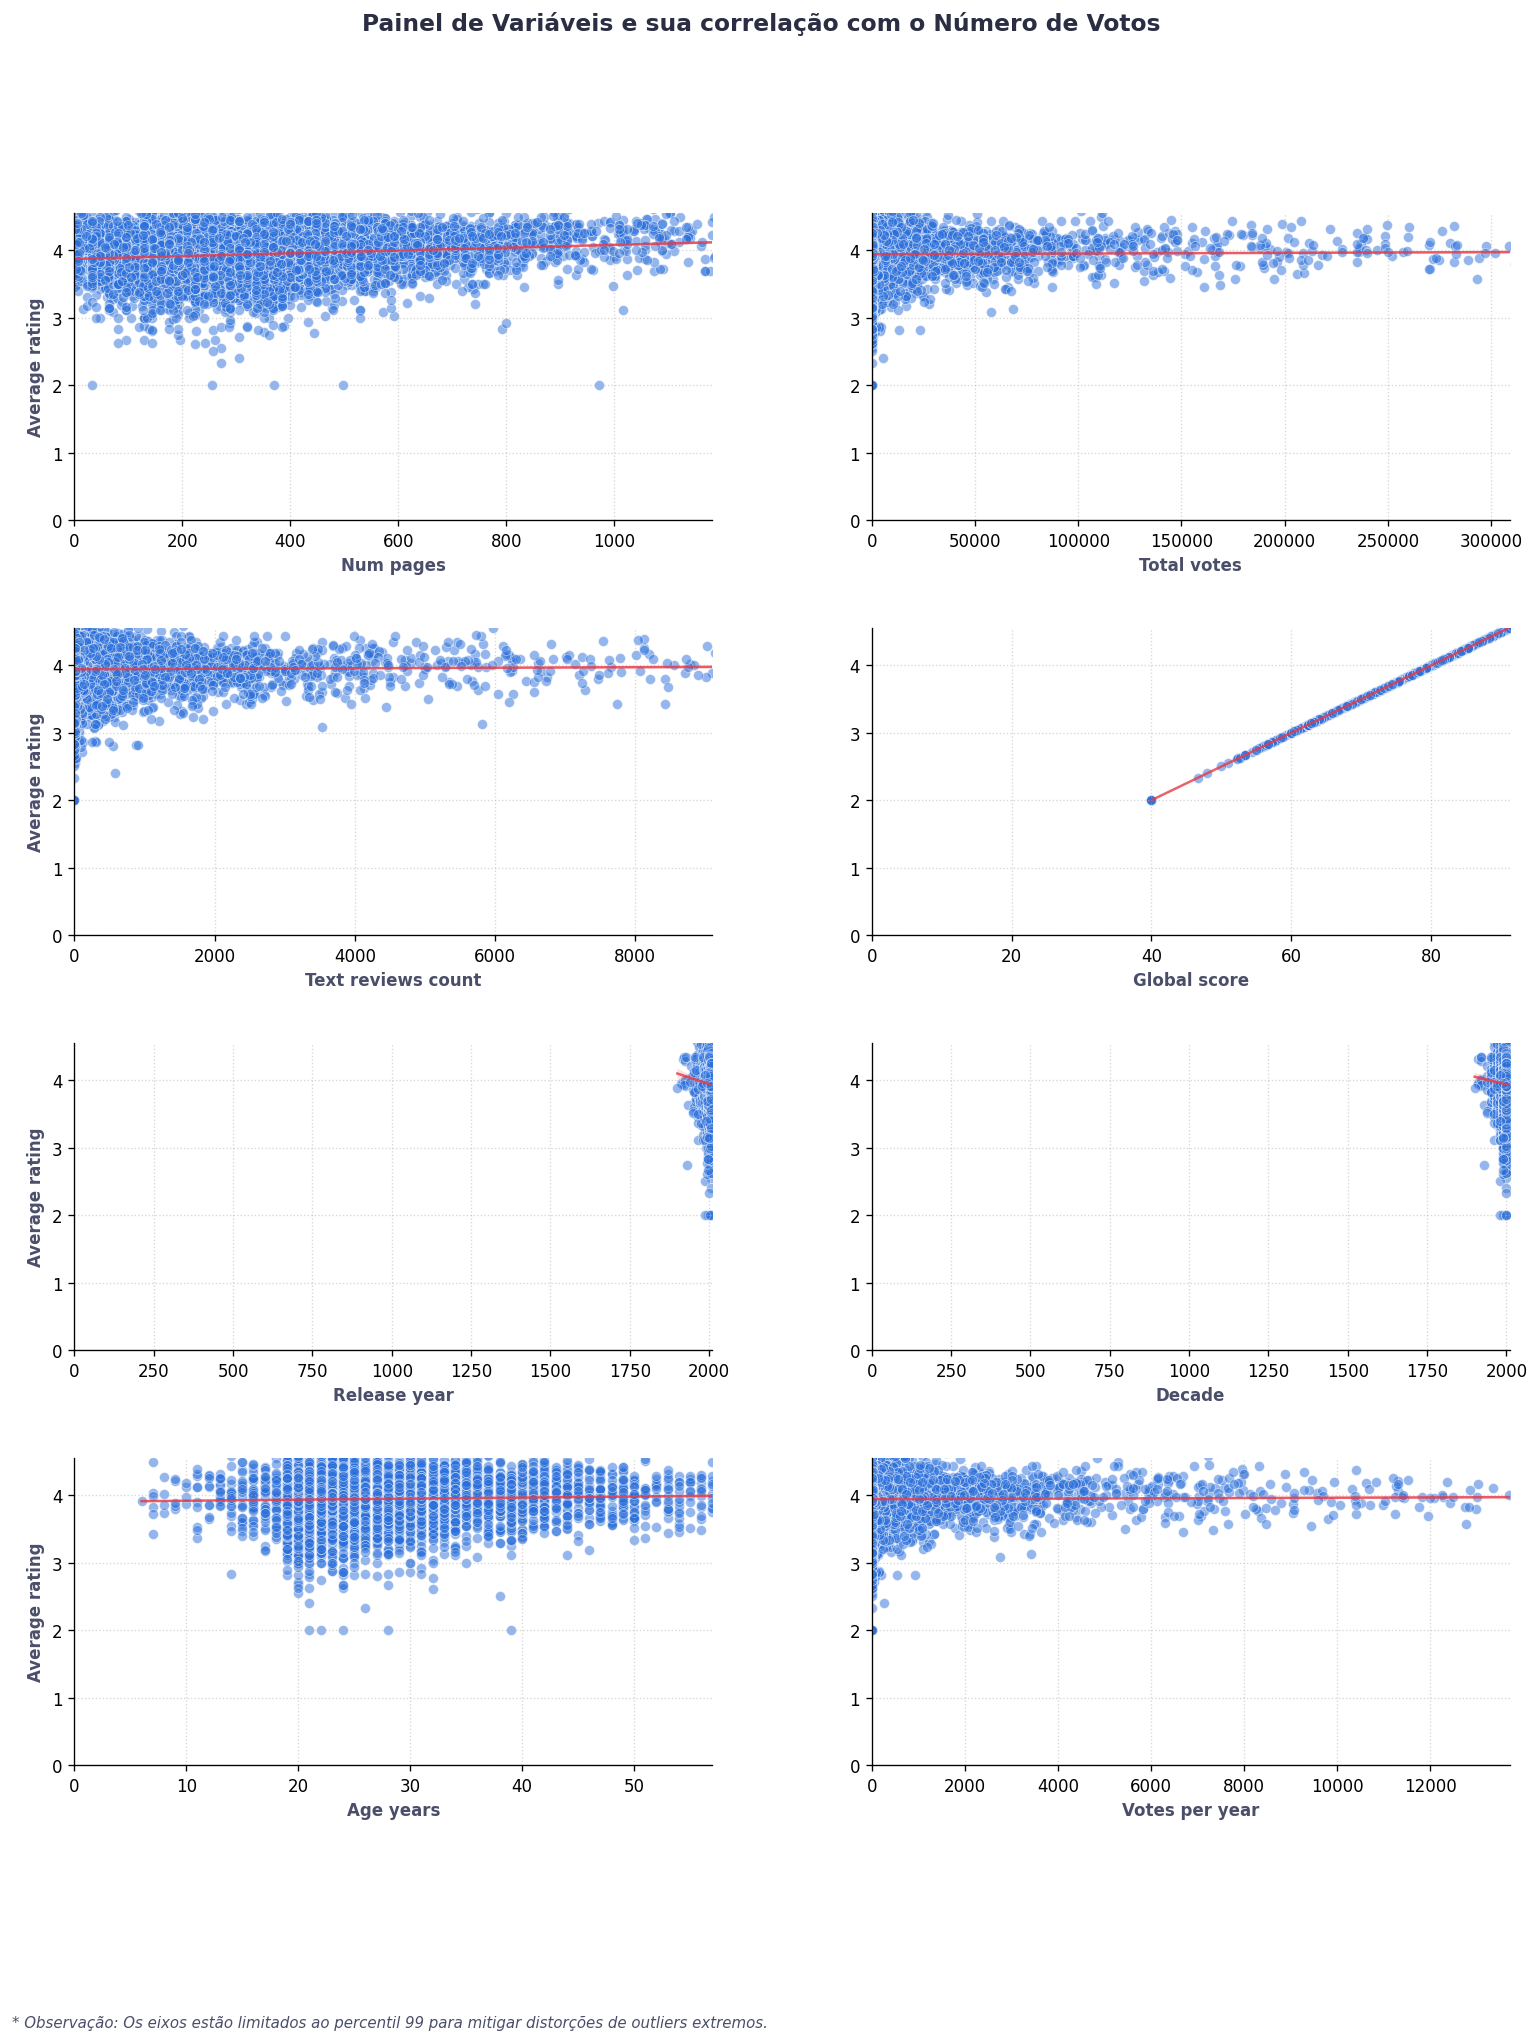

In [27]:
graf.grafico_corr_scatter(
    df_plot=df_books,
    coluna_x=colunas_numericas.drop(['average_rating', 'book_id']),
    coluna_y='average_rating',
    titulo='Painel de Variáveis e sua correlação com o Número de Votos',
    quant_grafs=len(colunas_numericas.drop(['average_rating', 'book_id']))
)

In [29]:
# Verificando a distribuição dos livros com pouquíssimos votos

display(tb.estilizar_tabela(
    df=df_books[df_books['total_votes'] <= 10]['total_votes']
        .value_counts()
        .sort_index()
        .to_frame(name='Contagem'),
    caption="Quantidade de livros por número de votos (de 0 a 10):"
))

# Verificando especificamente quem tem apenas 1 voto
apenas_um = (df_books['total_votes'] == 1).sum()
print(f"\nLivros que possuem exatamente 1 voto: {apenas_um}")

,Contagem
total_votes,
1,62
2,63
3,70
4,62
5,51
6,52
7,52
8,53
9,55



Livros que possuem exatamente 1 voto: 62


In [31]:
print(f"Total de livros com pouquíssimos votos: {
    df_books[df_books['total_votes'] <= 10]['total_votes']
        .values
        .sum()
}")

Total de livros com pouquíssimos votos: 3026


In [33]:
media = df_books[df_books['total_votes'] <= 10]['average_rating'].mean()

print(f"Média das notas dos livros com pouquíssimos votos (<= 10): {media:.2f}")

Média das notas dos livros com pouquíssimos votos (<= 10): 3.89


In [35]:
media = df_books[df_books['total_votes'] == 1]['average_rating'].mean()

print(f"Média das notas dos livros com apenas 1 voto: {media:.2f}")

Média das notas dos livros com apenas 1 voto: 3.77


---
## Categorica VS Categorica

### Carregando DataFrame Explodido

In [36]:
caminho = '../data/processed/books/goodreads_books_exploded.parquet'
df_exploded = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (94023, 18)


### `genres` vs `origina_language`

In [37]:
# Criar a Tabela de Contingência 

top_genres = df_exploded['genres'].value_counts().head(20).index
top_languages = df_exploded['original_language'].value_counts().head(20).index

contingencia_genres_language = pd.crosstab(
    df_exploded['original_language'], 
    df_exploded['genres']
)

display(tb.estilizar_tabela(
    df=contingencia_genres_language.loc[
        top_languages,
        top_genres
    ],
    caption='Tabela de Contingência (Valores Absolutos): original_language vs genres'
))

genres,Fiction,Classics,Nonfiction,Literature,Fantasy,Novels,"Historical,Historical Fiction",Audiobook,History,Mystery,Romance,Historical,Contemporary,Adventure,Young Adult,Adult,Philosophy,Science Fiction,Childrens,Humor
original_language,,,,,,,,,,,,,,,,,,,,
eng,5470,2725,2424,2343,1948,2017,1456,1331,1296,1294,1230,1160,1081,1002,964,986,971,914,878,877
en-US,766,308,504,250,330,240,168,163,216,171,177,143,142,143,155,142,165,147,172,152
spa,169,78,26,67,75,88,52,44,11,38,41,31,43,37,29,50,13,27,27,28
en-GB,104,52,80,44,37,45,31,18,39,18,22,25,18,19,22,26,28,20,26,21
fre,116,58,11,61,42,63,23,20,5,23,14,8,34,21,13,19,22,21,6,17
ger,78,34,13,35,23,45,18,21,6,16,22,15,28,14,15,21,11,8,7,18
jpn,39,0,0,0,36,0,10,0,0,3,23,0,1,18,32,1,0,5,0,2
zho,14,5,0,2,13,3,1,4,0,0,0,1,0,13,12,0,0,8,3,0
mul,8,15,4,12,2,1,1,1,6,0,1,1,0,0,0,0,3,0,0,0


In [38]:
# Executando o Teste do Qui-Quadrado
resultado_genres_language = mt.testar_dependencia_categorica(
    contingencia_genres_language
)

display(tb.estilizar_tabela(
    df=resultado_genres_language,
    caption='Relatório: language_code vs genres'
))

,Qui-Quadrado,p-valor,Graus de Liberdade
Hipótese Nula ($H_0$),,,
REJEITADA,49404.154639,0.000000,20424


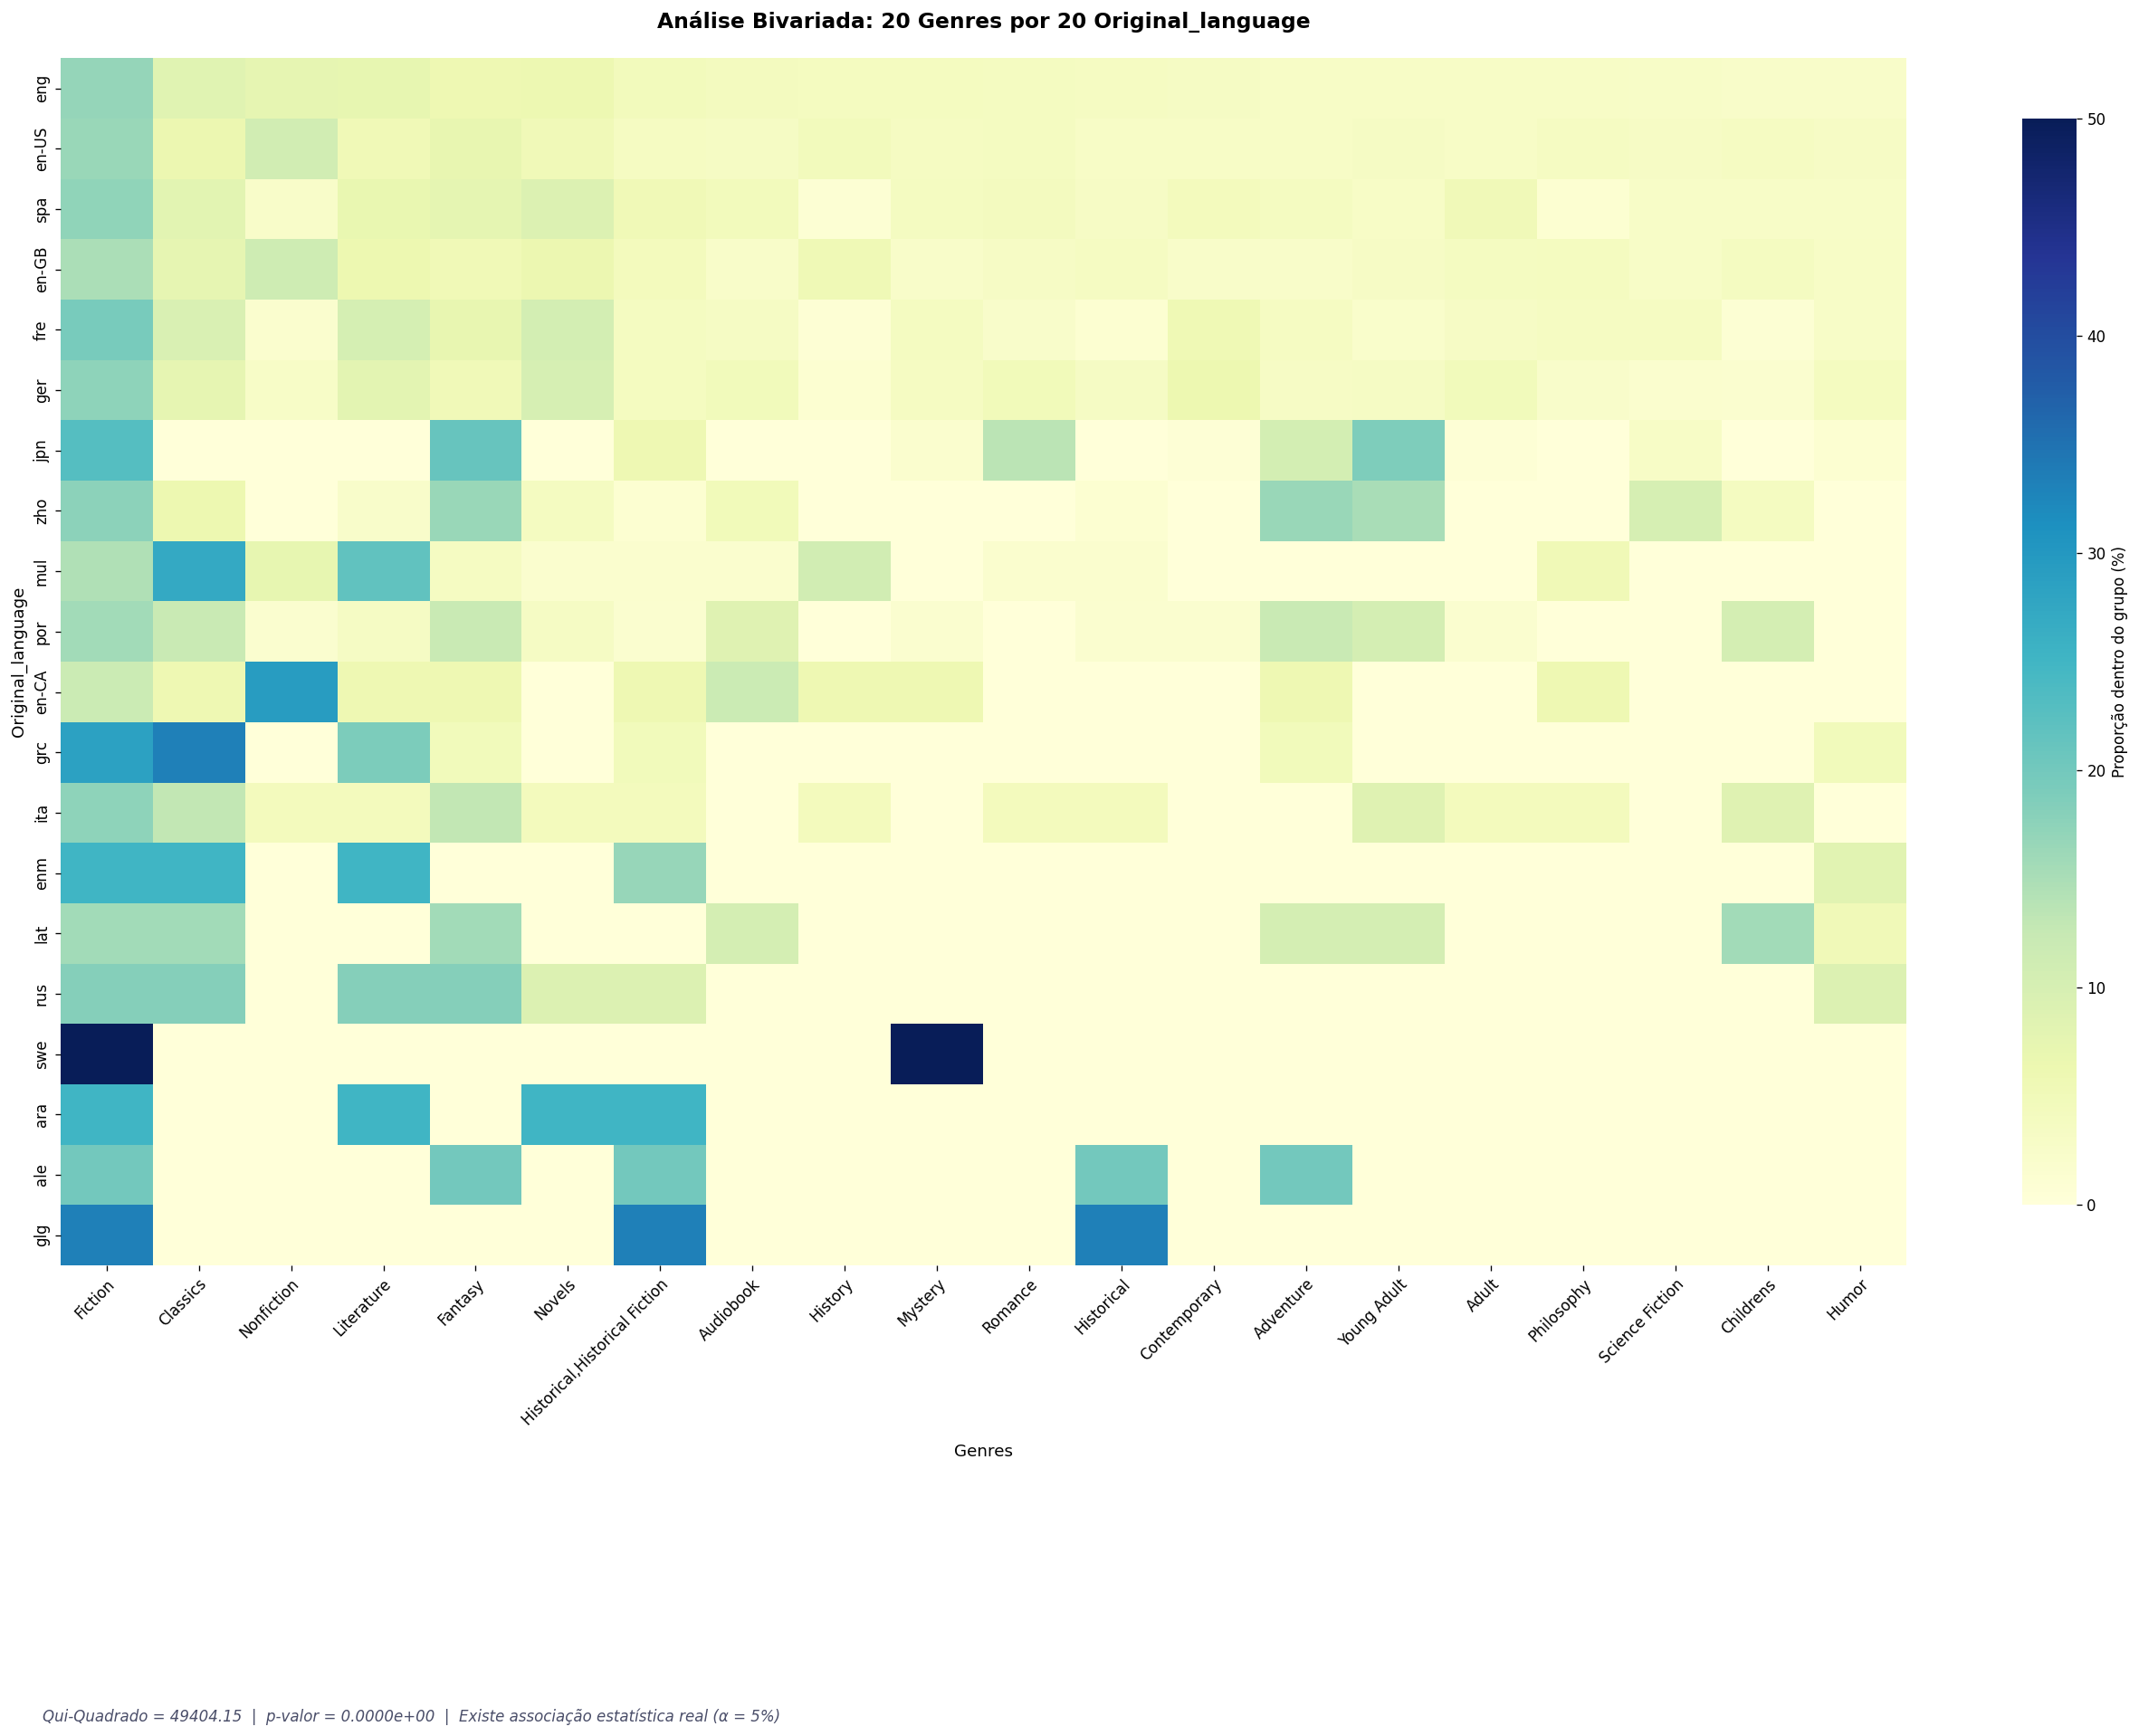

In [39]:
graf.grafico_dependencia_categorica(
    tabela_absoluta=contingencia_genres_language,
    chi2=resultado_genres_language['Qui-Quadrado'].iloc[0],
    p_valor=resultado_genres_language['p-valor'].iloc[0],
    top_n=20
)

### `genres` vs `producer_company`

In [40]:
# Criar a Tabela de Contingência 

top_genres = df_exploded['genres'].value_counts().head(20).index
top_publishers = df_exploded['producer_company'].value_counts().head(20).index

contingencia_genres_publisher = pd.crosstab(
    df_exploded['producer_company'], 
    df_exploded['genres']
)

display(tb.estilizar_tabela(
    df=contingencia_genres_publisher.loc[
        top_publishers,
        top_genres
    ],
    caption='Tabela de Contingência (Valores Absolutos): producer_company vs genres'
))

genres,Fiction,Classics,Nonfiction,Literature,Fantasy,Novels,"Historical,Historical Fiction",Audiobook,History,Mystery,Romance,Historical,Contemporary,Adventure,Young Adult,Adult,Philosophy,Science Fiction,Childrens,Humor
producer_company,,,,,,,,,,,,,,,,,,,,
Vintage,222,114,94,209,16,168,67,23,62,34,27,50,115,5,3,28,32,9,1,30
Penguin Books,177,142,80,148,22,112,77,43,50,30,26,50,43,20,10,29,33,15,6,28
Penguin Classics,139,180,43,161,28,83,60,11,34,7,33,30,6,15,4,0,48,5,3,11
Mariner Books,80,57,67,83,20,47,29,8,32,17,14,19,23,4,6,14,19,8,2,5
Ballantine Books,104,21,37,28,31,56,43,26,18,30,20,33,35,12,8,31,8,9,1,15
Pocket Books,96,11,11,4,32,18,22,29,4,53,31,16,11,28,17,37,2,19,2,7
Harper Perennial,57,23,52,54,6,46,29,13,30,5,9,25,34,8,2,16,25,2,1,9
HarperCollins,92,51,13,12,50,14,21,10,12,11,10,26,6,21,50,4,6,11,76,20
Bantam,84,12,21,10,31,23,27,27,9,37,26,27,15,13,10,27,9,15,8,10


In [41]:
# Executando o Teste do Qui-Quadrado
resultado_genres_publisher = mt.testar_dependencia_categorica(
    contingencia_genres_publisher
)

display(tb.estilizar_tabela(
    df=resultado_genres_publisher,
    caption='Relatório: publisher_code vs genres'
))

,Qui-Quadrado,p-valor,Graus de Liberdade
Hipótese Nula ($H_0$),,,
REJEITADA,3535008.573057,0.000000,1889220


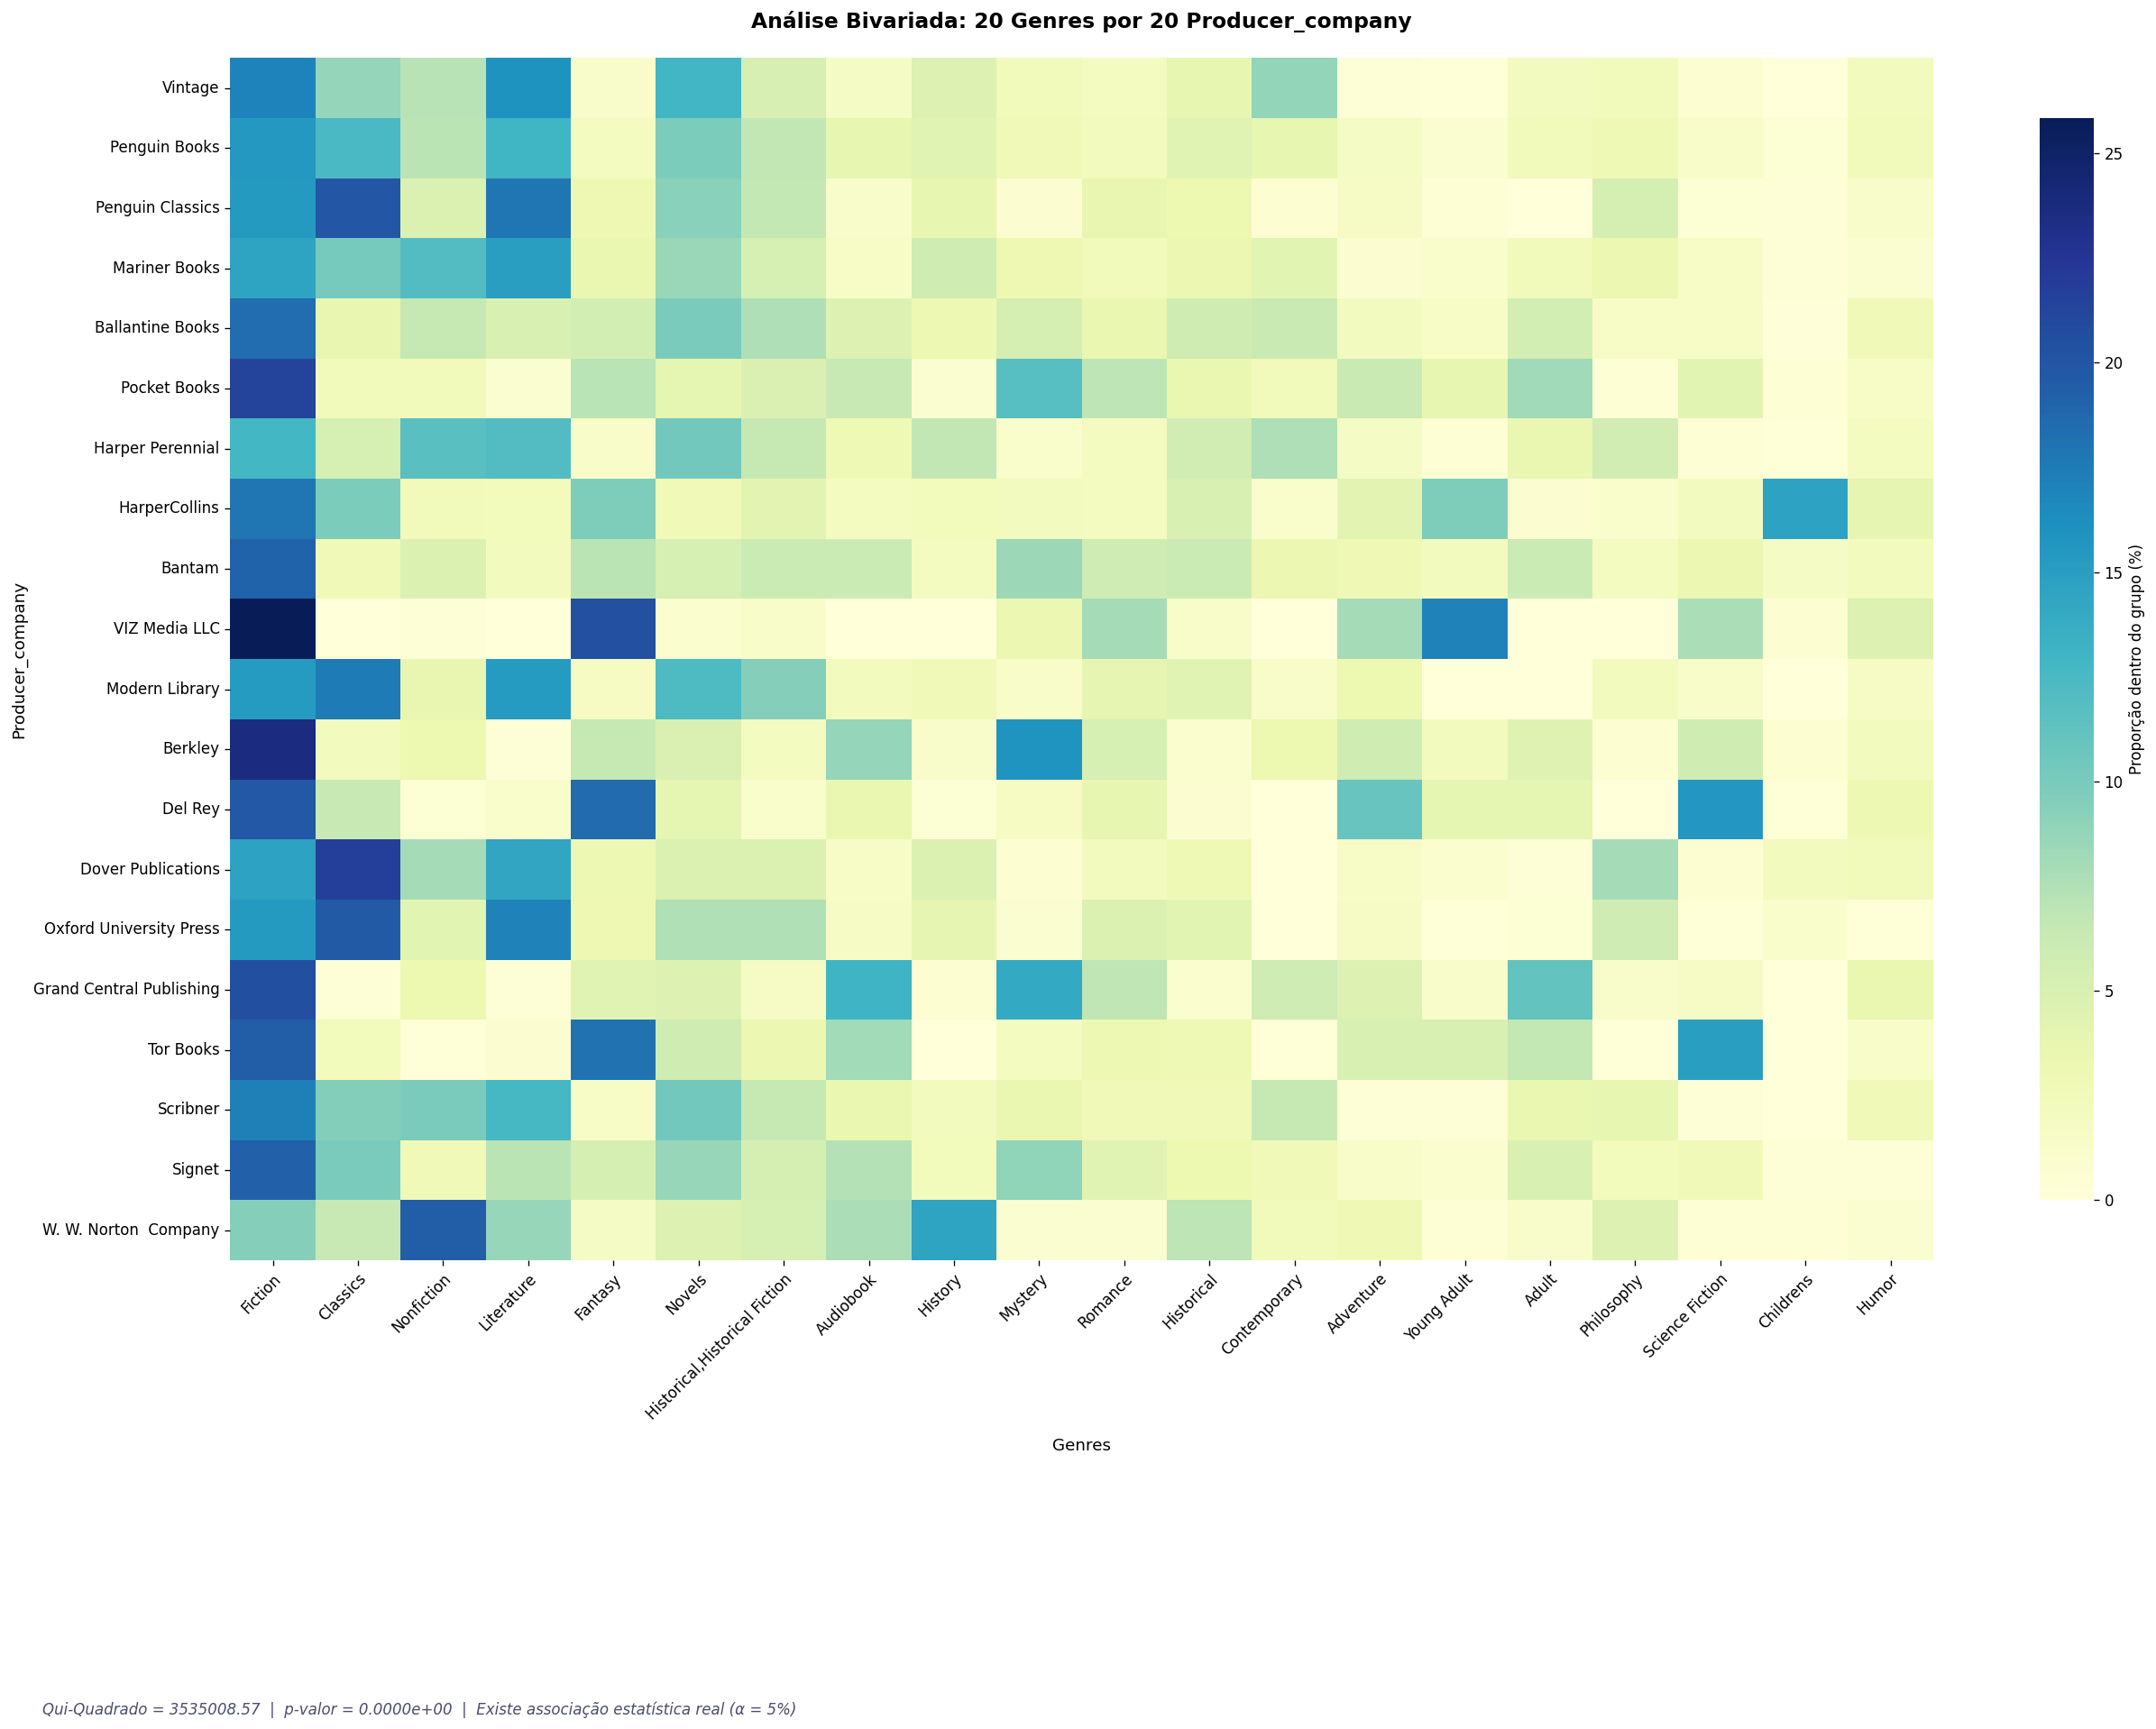

In [42]:
graf.grafico_dependencia_categorica(
    tabela_absoluta=contingencia_genres_publisher,
    chi2=resultado_genres_publisher['Qui-Quadrado'].iloc[0],
    p_valor=resultado_genres_publisher['p-valor'].iloc[0],
    top_n=20
)

### `original_language` vs `producer_company`

In [43]:
# Criar a Tabela de Contingência 

top_languages = df_exploded['original_language'].value_counts().head(20).index
top_publishers = df_exploded['producer_company'].value_counts().head(20).index

contingencia_language_publisher = pd.crosstab(
    df_exploded['original_language'], 
    df_exploded['producer_company']
)

display(tb.estilizar_tabela(
    df=contingencia_language_publisher.loc[
        top_languages,
        top_publishers,
    ],
    caption='Tabela de Contingência (Valores Absolutos): producer_company vs original_language'
))

producer_company,Vintage,Penguin Books,Penguin Classics,Mariner Books,Ballantine Books,Pocket Books,Harper Perennial,HarperCollins,Bantam,VIZ Media LLC,Modern Library,Berkley,Del Rey,Dover Publications,Oxford University Press,Grand Central Publishing,Tor Books,Scribner,Signet,W. W. Norton Company
original_language,,,,,,,,,,,,,,,,,,,,
eng,2889,2239,1574,1103,1175,832,861,804,926,740,754,704,672,615,685,638,468,611,560,528
en-US,151,207,153,236,155,190,150,178,70,109,57,61,67,65,20,49,218,51,74,87
spa,10,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0,0
en-GB,56,70,80,10,0,20,0,17,0,10,0,0,8,0,3,20,0,0,2,20
fre,0,0,0,10,0,0,0,0,0,0,0,0,0,8,0,0,0,0,0,0
ger,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0
jpn,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
zho,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
mul,0,0,0,0,0,0,0,0,0,0,0,0,0,13,0,0,0,0,0,0


In [44]:
# Executando o Teste do Qui-Quadrado
resultado_language_publisher = mt.testar_dependencia_categorica(
    contingencia_language_publisher
)

display(tb.estilizar_tabela(
    df=resultado_language_publisher,
    caption='Relatório: publisher_code vs language_code'
))

,Qui-Quadrado,p-valor,Graus de Liberdade
Hipótese Nula ($H_0$),,,
REJEITADA,1530418.642898,0.000000,53280


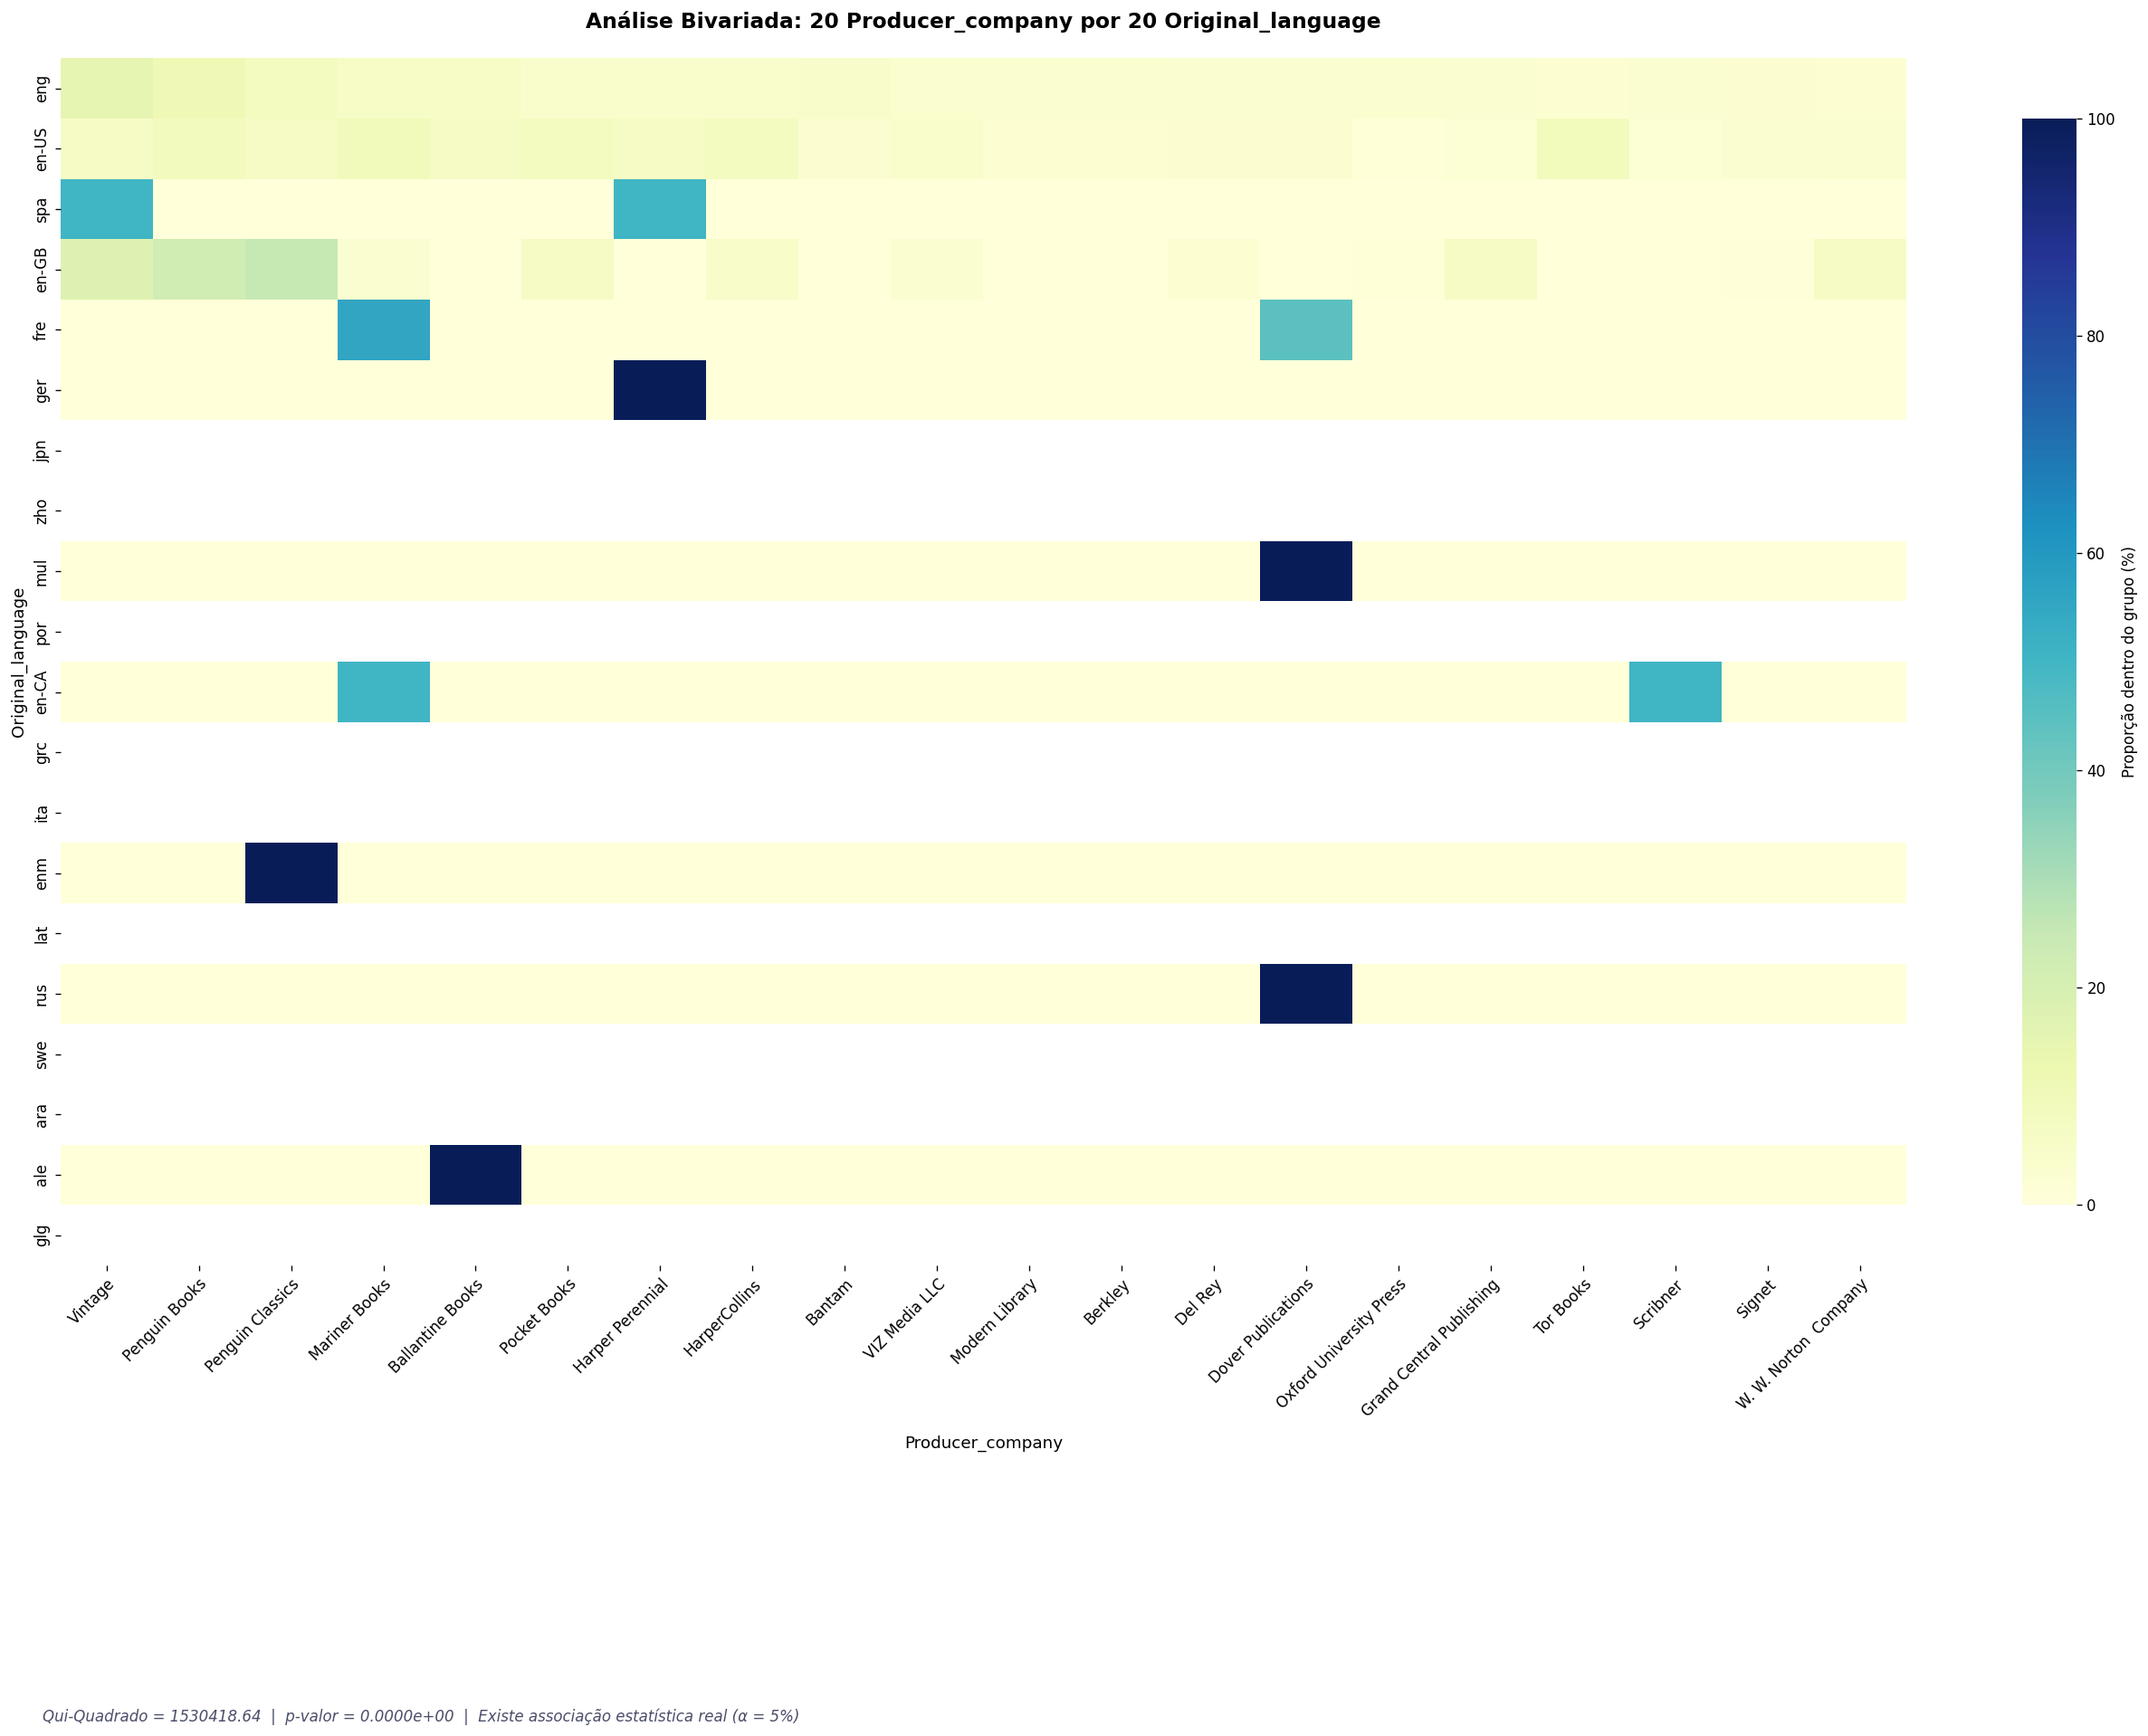

In [45]:
graf.grafico_dependencia_categorica(
    tabela_absoluta=contingencia_language_publisher,
    chi2=resultado_language_publisher['Qui-Quadrado'].iloc[0],
    p_valor=resultado_language_publisher['p-valor'].iloc[0],
    top_n=20
)

---
## Categorica VS Numérica